# **WALMART CASE STUDY**

# Walmart Black Friday Customer Analytics

# **1️⃣ Problem Statement + Basic Metrics**



## 1. Problem Statement

Walmart wants to understand customer purchasing behavior during Black Friday.
The primary objective is to analyze the purchase amount across different customer
segments such as gender, age, marital status, city category, occupation, and
product category.

A key business question is:

**Do female customers spend more per transaction than male customers on Black Friday?**

The analysis will use sample transaction data to compare customer spending patterns
and use statistical techniques such as the Central Limit Theorem and Confidence
Intervals to make inferences about the larger customer population.

# 2. Load & Basic Structur

In [1]:
pip install -q gdown

In [2]:
!gdown "1-jA_Hok_LhCcRwW6-kHt0RnsGPmEgH6y"

Downloading...
From: https://drive.google.com/uc?id=1-jA_Hok_LhCcRwW6-kHt0RnsGPmEgH6y
To: /content/walmart_data.csv
100% 23.0M/23.0M [00:00<00:00, 59.8MB/s]


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("walmart_data.csv")

In [5]:
!ls

sample_data  walmart_data.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
walmart = df.copy()
walmart.head()


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [8]:
walmart.shape


(550068, 10)

In [9]:
walmart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


# 3.Statistical Summary

In [10]:
walmart.describe()

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,23961.000000


In [11]:
walmart["Purchase"].describe()

,Purchase
count,550068.000000
mean,9263.968713
std,5023.065394
min,12.000000
25%,5823.000000
50%,8047.000000
75%,12054.000000
max,23961.000000


# 4.Unique Values, Null Values, Duplicate Values & Value Counts

In [12]:
walmart.nunique()

,0
User_ID,5891
Product_ID,3631
Gender,2
Age,7
Occupation,21
City_Category,3
Stay_In_Current_City_Years,5
Marital_Status,2
Product_Category,20
Purchase,18105


In [13]:
walmart.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


In [14]:
walmart.duplicated().sum()

np.int64(0)

In [15]:
walmart["Gender"].value_counts()


,count
Gender,
M,414259
F,135809


In [16]:
walmart["Age"].value_counts()


,count
Age,
26-35,219587
36-45,110013
18-25,99660
46-50,45701
51-55,38501
55+,21504
0-17,15102


In [17]:
walmart["Product_Category"].value_counts()

,count
Product_Category,
5,150933
1,140378
8,113925
11,24287
2,23864
6,20466
3,20213
4,11753
16,9828


In [18]:
walmart["Marital_Status"].value_counts()

,count
Marital_Status,
0,324731
1,225337


In [19]:
walmart["Stay_In_Current_City_Years"].value_counts()


,count
Stay_In_Current_City_Years,
1,193821
2,101838
3,95285
4+,84726
0,74398


In [20]:
walmart["City_Category"].value_counts()


,count
City_Category,
B,231173
C,171175
A,147720


In [21]:
walmart["Occupation"].value_counts()


,count
Occupation,
4,72308
0,69638
7,59133
1,47426
17,40043
20,33562
12,31179
14,27309
2,26588


# 5.Convert Categorical Columns

In [22]:
cat_cols = [
    "Gender",
    "Age",
    "Occupation",
    "City_Category",
    "Stay_In_Current_City_Years",
    "Marital_Status",
    "Product_Category"
]

walmart[cat_cols] = walmart[cat_cols].astype("category")

In [23]:
walmart.dtypes

,0
User_ID,int64
Product_ID,object
Gender,category
Age,category
Occupation,category
City_Category,category
Stay_In_Current_City_Years,category
Marital_Status,category
Product_Category,category
Purchase,int64


# **2️⃣ Missing + Outliers**

# Part A — Missing Value Analysis

Step 1: Count missing values


In [24]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


**Observation:** The dataset contains no missing values across any of the 10 attributes. Therefore, no missing-value treatment or imputation is required.

Step 2: Missing-value percentage

In [25]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": df.isnull().mean() * 100
})

missing

,Missing Values,Percentage
User_ID,0,0.0
Product_ID,0,0.0
Gender,0,0.0
Age,0,0.0
Occupation,0,0.0
City_Category,0,0.0
Stay_In_Current_City_Years,0,0.0
Marital_Status,0,0.0
Product_Category,0,0.0
Purchase,0,0.0


Step 3: Visualize missing values


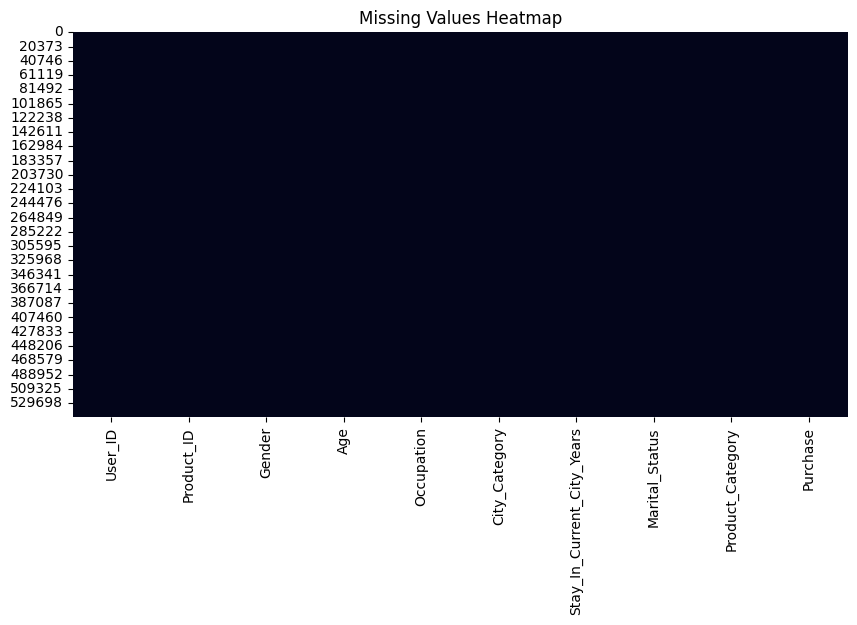

In [26]:
plt.figure(figsize=(10, 5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

# Part B — Outlier Analysis

# Step 4: Boxplot

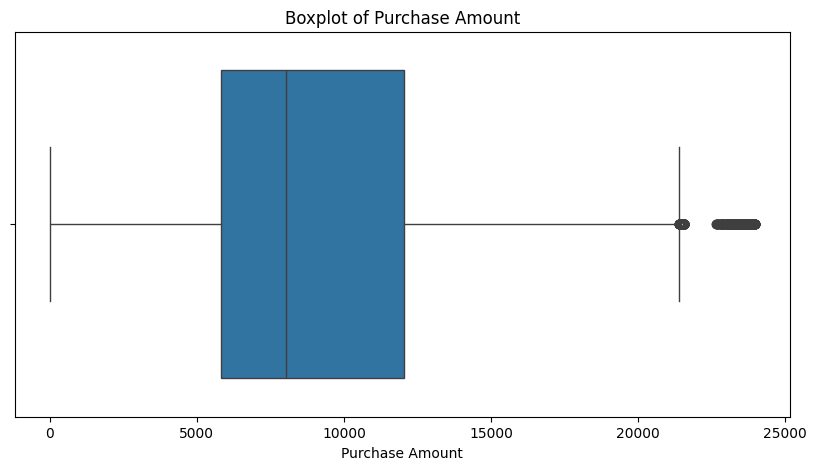

In [27]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["Purchase"])

plt.title("Boxplot of Purchase Amount")
plt.xlabel("Purchase Amount")

plt.show()

Step 5: Use IQR Method

Calculate Q1 and Q3

In [28]:
Q1 = df["Purchase"].quantile(0.25)
Q3 = df["Purchase"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 5823.0
Q3: 12054.0
IQR: 6231.0


Calculate boundaries

In [29]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -3523.5
Upper Bound: 21400.5


Count potential outliers


In [30]:
outliers = df[
    (df["Purchase"] < lower_bound) |
    (df["Purchase"] > upper_bound)
]

print("Number of potential outliers:", len(outliers))

Number of potential outliers: 2677


Calculate percentage


In [31]:
outlier_percentage = len(outliers) / len(df) * 100

print("Outlier Percentage:", outlier_percentage)

Outlier Percentage: 0.4866671029763593


**Observation:** Using the IQR method, 2,677 transactions, approximately 0.49% of the dataset, are identified as potential outliers in the Purchase variable. These observations are mainly on the higher side of the purchase range.

Step 6: Compare Mean vs Median

In [32]:
print("Mean Purchase:", df["Purchase"].mean())
print("Median Purchase:", df["Purchase"].median())

Mean Purchase: 9263.968712959126
Median Purchase: 8047.0


Observation: The mean purchase amount 9,263.97 doller is higher than the median
 8,047 doller, indicating a right-skewed distribution. Higher-value transactions are likely contributing to the increase in the mean.

Step 7: Distribution of Purchase

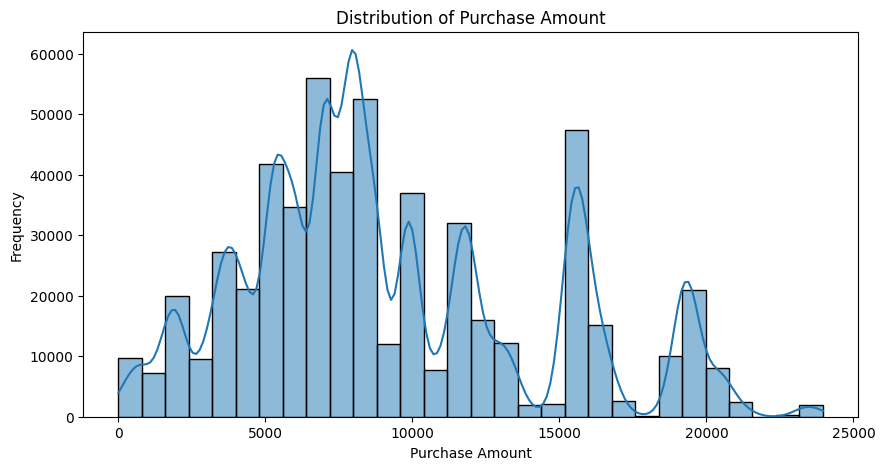

In [33]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Purchase",
    bins=30,
    kde=True
)

plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")

plt.show()

**Observation:** The Purchase distribution is multimodal, with multiple noticeable peaks across the purchase range. The distribution is also right-skewed, with relatively fewer high-value transactions extending toward the upper end.

# **3️⃣ Business Insights — Univariate & Bivariate Analysis**

# 3.1 Gender Distribution

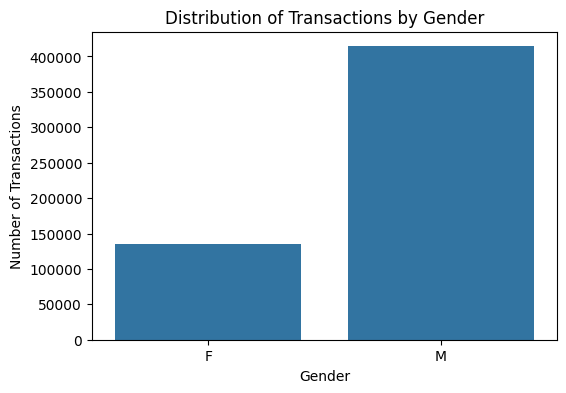

In [34]:
plt.figure(figsize=(6,4))

sns.countplot(data=walmart, x="Gender")

plt.title("Distribution of Transactions by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")

plt.show()

**Observation:** The dataset contains substantially more transactions from male customers than female customers. Therefore, the sample is gender-imbalanced, with male customers accounting for the majority of transactions.

# 3.2 Age Group Distribution

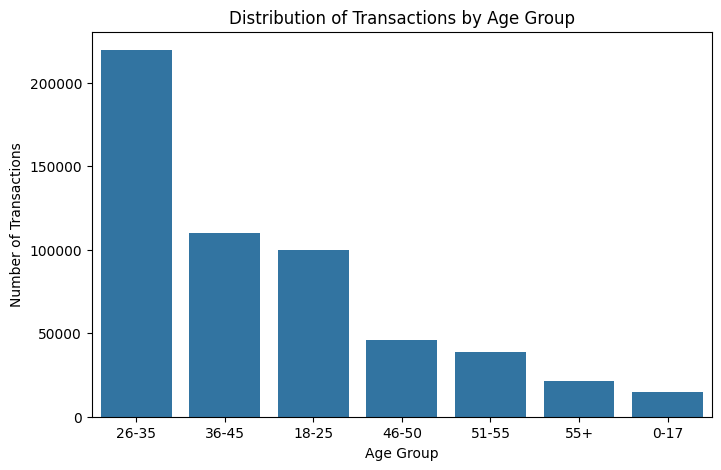

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=walmart,
    x="Age",
    order=walmart["Age"].value_counts().index
)

plt.title("Distribution of Transactions by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")

plt.show()

**Observation: **The 26–35 age group accounts for the highest number of transactions, followed by the 36–45 and 18–25 groups. Transaction activity decreases considerably among customers aged 46 and above, while the 0–17 group has the lowest representation.


**Business Insight:** Walmart's Black Friday transaction activity is concentrated among customers aged 18–45, particularly the 26–35 segment. This segment could be an important target for Black Friday campaigns.

# 3.3 Purchase Distribution

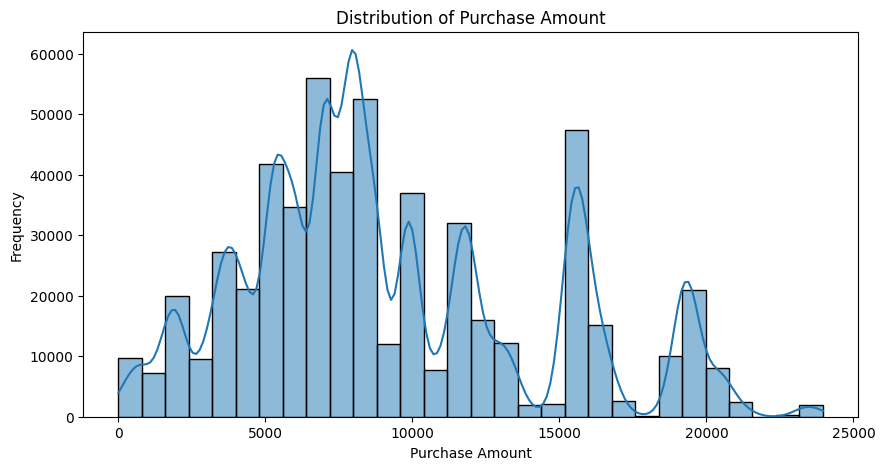

In [36]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=walmart,
    x="Purchase",
    bins=30,
    kde=True
)

plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")

plt.show()

**Observation:** Purchase amounts are distributed across a wide range, with most transactions concentrated between ₹5,000 and ₹10,000. The distribution shows multiple peaks and is not normally distributed. Higher purchase amounts occur less frequently compared with the central range.

**Business Insight:** Walmart can focus on products and promotions within the commonly observed spending range while using targeted offers to encourage higher-value purchases.

# 3.4 Gender vs Purchase

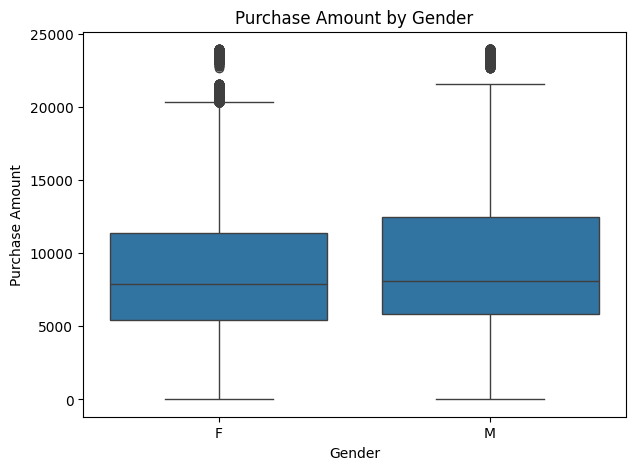

In [37]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=walmart,
    x="Gender",
    y="Purchase"
)

plt.title("Purchase Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Purchase Amount")

plt.show()

# Observation:
Male customers have a slightly higher median purchase amount than female customers. The overall purchase distributions of both genders are fairly similar, although male customers show a slightly higher central tendency. Both groups also contain some high-value potential outliers.


# Business Insight:
 Based on the sample, male customers appear to spend slightly more per transaction than female customers. However, this difference should be validated statistically using confidence intervals before making a business decision.

# 3.5 Age vs Purchase

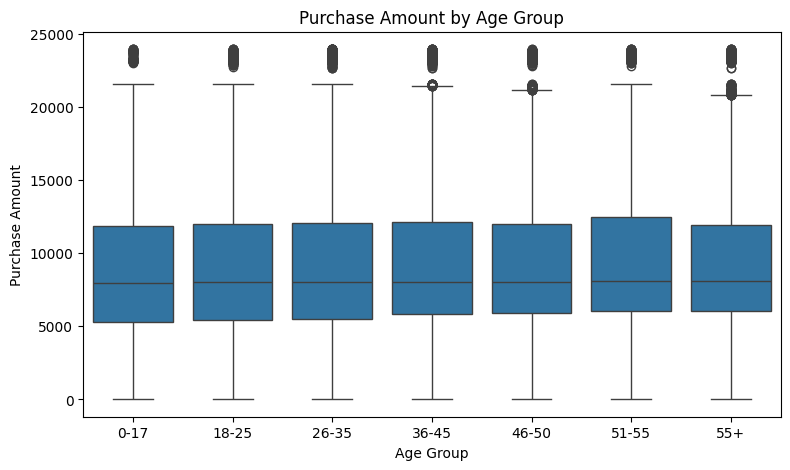

In [38]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=walmart,
    x="Age",
    y="Purchase"
)

plt.title("Purchase Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Purchase Amount")

plt.show()

# Observation:
Purchase amounts show a similar distribution across the different age groups, with considerable overlap in their medians and ranges. The 51–55 age group shows a slightly higher upper range, while all age groups contain some high-value potential outliers.

# Business Insight:
Age alone does not appear to create a large difference in purchase amount. Walmart should therefore consider age along with other customer characteristics when designing targeted promotions.

# 3.6 Marital Status vs Purchase

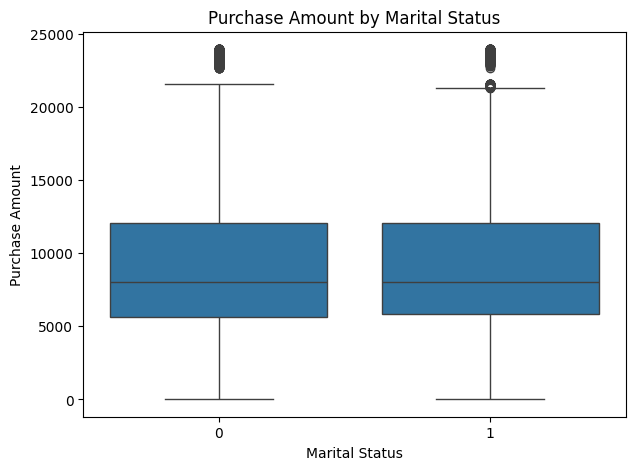

In [39]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=walmart,
    x="Marital_Status",
    y="Purchase"
)

plt.title("Purchase Amount by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Purchase Amount")

plt.show()

# Observation:
 The purchase distributions for married and unmarried customers are very similar. Both groups have nearly identical median purchase amounts and comparable ranges, indicating that marital status does not appear to have a major impact on purchase amount based on the visual analysis.

# Business Insight:
 Walmart may not need to treat marital status as a primary factor when designing purchase-value strategies. Other factors such as gender, age, product category, and customer preferences may provide more useful segmentation opportunities.

# 3.7 City Category vs Purchase

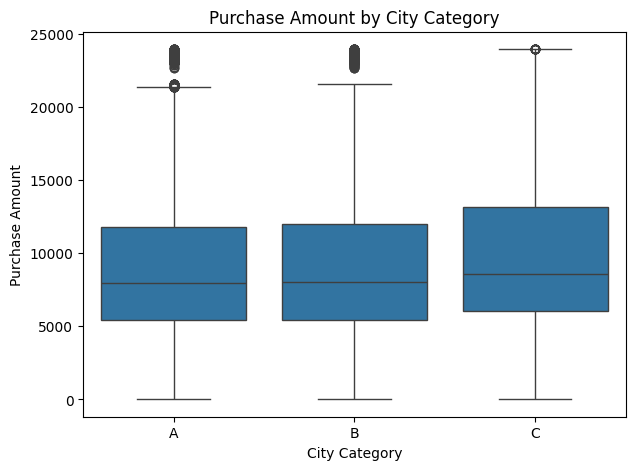

In [40]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=walmart,
    x="City_Category",
    y="Purchase"
)

plt.title("Purchase Amount by City Category")
plt.xlabel("City Category")
plt.ylabel("Purchase Amount")

plt.show()

# Observation:
Customers from City Category C have the highest median purchase amount compared with Categories A and B. Categories A and B have very similar median purchase values. City C also shows a slightly wider spread in purchase amounts. All three categories contain some high-value transactions, indicating the presence of potential outliers.

# Business Insight:
Customers in City Category C appear to have higher spending per transaction, suggesting that Walmart could explore customer-specific promotions and product strategies for this market.

# 3.8 Product Category vs Purchase

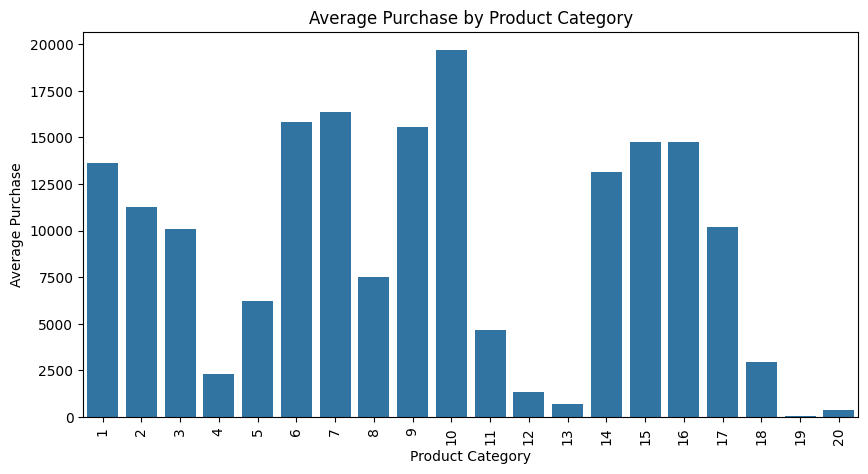

In [41]:
plt.figure(figsize=(10,5))

avg_purchase_category = (
    walmart.groupby("Product_Category", observed=True)["Purchase"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=avg_purchase_category.index,
    y=avg_purchase_category.values
)

plt.title("Average Purchase by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Purchase")

plt.xticks(rotation=90)

plt.show()

# Observation:
Product Category 10 has the highest average purchase amount, followed by Categories 7, 6, and 9. Categories 19, 13, and 12 have comparatively low average purchase amounts. This indicates substantial variation in average spending across product categories.


# Business Insight:
 Walmart can focus on high-value product categories such as 10, 7, 6, and 9 for premium promotions and cross-selling opportunities, while investigating whether low-average categories can benefit from bundling or promotional strategies.

# 3.9 Age + Gender vs Purchase

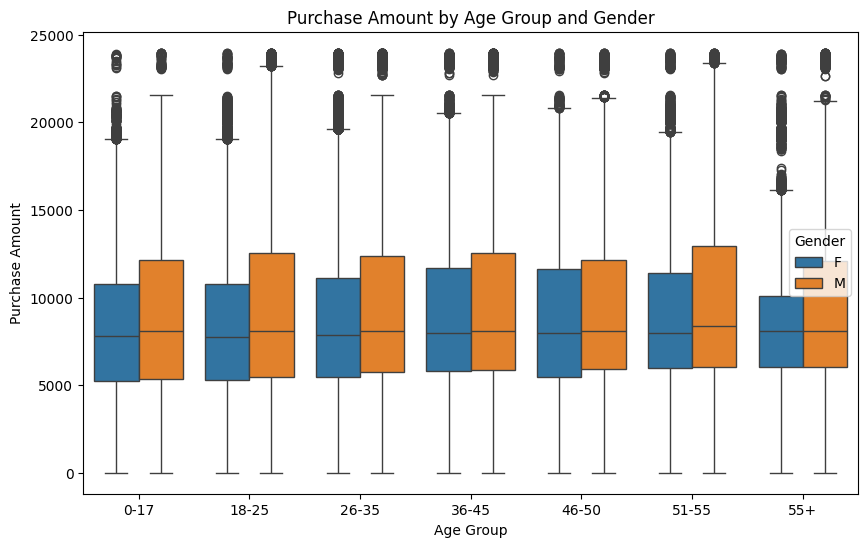

In [42]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=walmart,
    x="Age",
    y="Purchase",
    hue="Gender"
)

plt.title("Purchase Amount by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Purchase Amount")

plt.show()

# Observation:
Across almost all age groups, male customers have a higher median purchase amount than female customers. The difference is relatively consistent across age groups. Both genders also show a wide range of purchase amounts and several high-value potential outliers.

# Business Insight:
The gender-based spending difference appears to persist across different age groups. This suggests that Walmart may need to consider both age and gender together when designing customer promotions rather than using a single broad customer strategy.

# **4️⃣ Main Questions Gender, CI, Married, Age**

# 4.1 Male vs Female Spending

Business Question
Are women spending more money per transaction than men? Why or why not?

Step 1 — Calculate average purchase by gender

In [43]:
gender_purchase = walmart.groupby("Gender", observed=True)["Purchase"].agg(
    ["count", "mean", "median", "std"]
)

gender_purchase

,count,mean,median,std
Gender,,,,
F,135809,8734.565765,7914.0,4767.233289
M,414259,9437.526040,8098.0,5092.186210


# Observation:
 Male customers have a higher average purchase amount (₹9,437.53) compared with female customers (₹8,734.57). The average male transaction is approximately 8.05% higher than the average female transaction. The median purchase amount also follows the same pattern, indicating that male customers tend to spend more per transaction in the sample.

Step 2 — Calculate total purchase

In [44]:
gender_total = walmart.groupby("Gender", observed=True)["Purchase"].sum()

gender_total

,Purchase
Gender,
F,1186232642
M,3909580100


# Observation:
Male customers contribute a substantially higher total purchase amount than female customers. However, this is largely influenced by the fact that the dataset contains many more male transactions. Therefore, total purchase should not be used to conclude who spends more per transaction

Step 3 — Calculate percentage difference

In [45]:
male_avg = gender_purchase.loc["M", "mean"]
female_avg = gender_purchase.loc["F", "mean"]

percentage_difference = ((male_avg - female_avg) / female_avg) * 100

print("Percentage difference:", percentage_difference)

Percentage difference: 8.048027735060238


Step 4 — Visualize average purchase

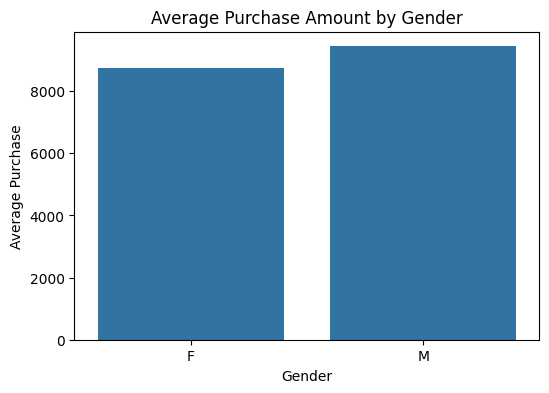

In [46]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=walmart,
    x="Gender",
    y="Purchase",
    estimator="mean",
    errorbar=None
)

plt.title("Average Purchase Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Purchase")

plt.show()

# Observation:
The average purchase amount for male customers is higher than that of female customers. Male customers spend approximately ₹9,437.53 per transaction, compared with ₹8,734.57 for female customers.

# Business Interpretation
Male customers spend approximately 8.05% more per transaction than female customers in the sample.

Step 5 — Compare distributions

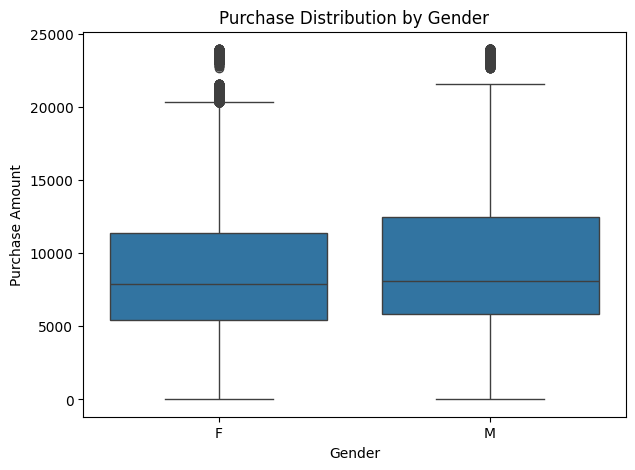

In [47]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=walmart,
    x="Gender",
    y="Purchase"
)

plt.title("Purchase Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Purchase Amount")

plt.show()

# Observation:
Male customers have a slightly higher median purchase amount than female customers. The male distribution also shows a somewhat wider spread. Both groups contain several high-value potential outliers.


# Business Insight:
The boxplot supports the earlier finding that male customers tend to spend more per transaction. However, the distributions overlap substantially, so the difference should be validated statistically before making a population-level conclusion.

### Finding

The average purchase amount for **male customers is ₹9,437.53**, while female customers spend **₹8,734.57** on average.

### Comparison

Male customers spend approximately **8.05% more per transaction** than female customers.

### Conclusion

Based on the sample, **male customers have a higher average spending per transaction** than female customers.




# 4.2  Central Limit Theorem + Confidence Intervals

In [48]:
gender_purchase = walmart.groupby("Gender", observed=True)["Purchase"].agg(
    ["count", "mean", "median", "std"]
)

gender_purchase

,count,mean,median,std
Gender,,,,
F,135809,8734.565765,7914.0,4767.233289
M,414259,9437.526040,8098.0,5092.186210


In [49]:
gender_total = walmart.groupby("Gender", observed=True)["Purchase"].sum()

gender_total

,Purchase
Gender,
F,1186232642
M,3909580100


# Step 1 — Create Male & Female Purchase Samples

In [50]:
female_purchase = walmart[walmart["Gender"] == "F"]["Purchase"]
male_purchase = walmart[walmart["Gender"] == "M"]["Purchase"]

In [51]:
print("Female transactions:", len(female_purchase))
print("Male transactions:", len(male_purchase))

Female transactions: 135809
Male transactions: 414259


Step 2 — Demonstrate CLT

In [52]:
sample_size = 30
n_samples = 1000

female_means = [
    female_purchase.sample(sample_size, replace=True).mean()
    for _ in range(n_samples)
]

male_means = [
    male_purchase.sample(sample_size, replace=True).mean()
    for _ in range(n_samples)
]

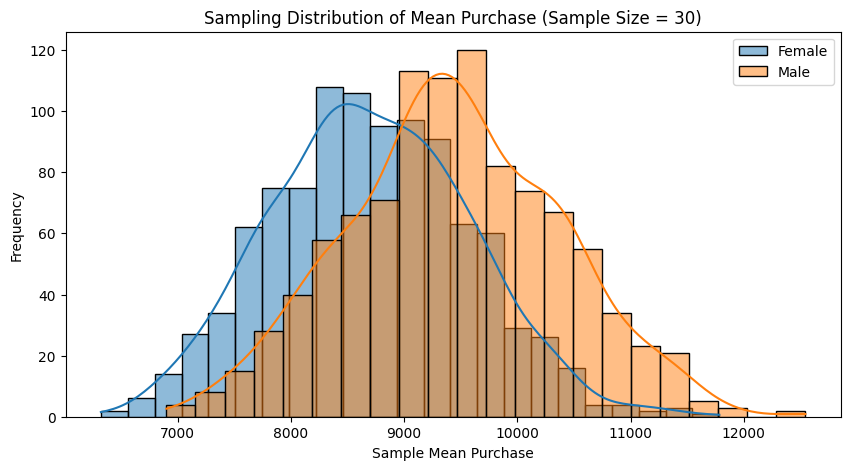

In [53]:
plt.figure(figsize=(10,5))

sns.histplot(female_means, kde=True, label="Female", alpha=0.5)
sns.histplot(male_means, kde=True, label="Male", alpha=0.5)

plt.title("Sampling Distribution of Mean Purchase (Sample Size = 30)")
plt.xlabel("Sample Mean Purchase")
plt.ylabel("Frequency")
plt.legend()

plt.show()

# CLT Observation:
 For a sample size of 30, the sampling distributions of the mean purchase for both male and female customers are approximately bell-shaped. The male distribution is centered at a higher purchase value than the female distribution, while the overlap indicates sampling variability between the two groups.

Step 3 — See the Effect of Sample Size

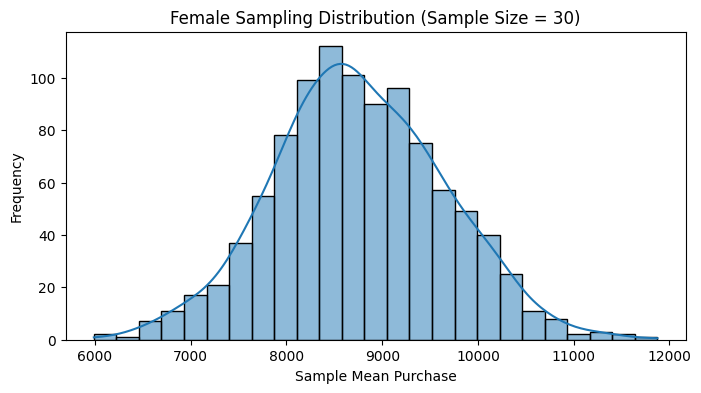

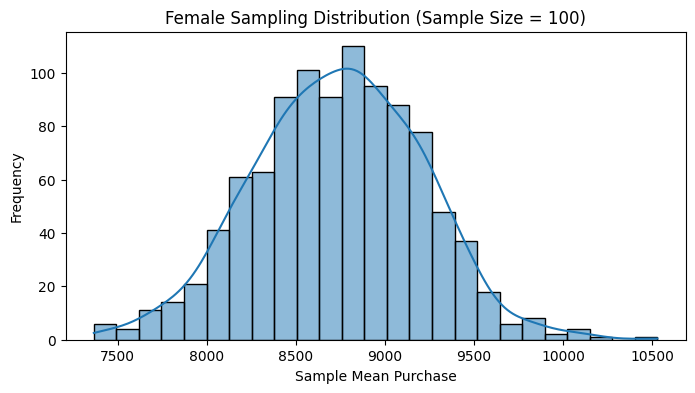

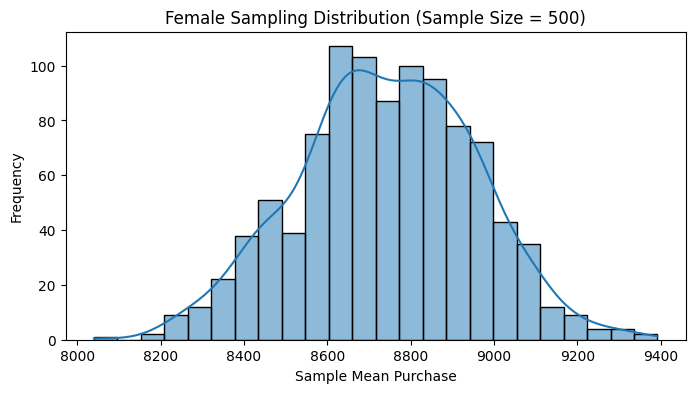

In [54]:
sample_sizes = [30, 100, 500]

for size in sample_sizes:

    female_means = [
        female_purchase.sample(size, replace=True).mean()
        for _ in range(1000)
    ]

    plt.figure(figsize=(8,4))

    sns.histplot(female_means, kde=True)

    plt.title(f"Female Sampling Distribution (Sample Size = {size})")
    plt.xlabel("Sample Mean Purchase")
    plt.ylabel("Frequency")

    plt.show()

# Observation:
As the sample size increases from 30 to 100 and 500, the sampling distribution of the female sample mean becomes narrower and more concentrated around the mean. This indicates that larger samples reduce sampling variability and provide more stable estimates of the population mean.

# 4.3 Confidence Interval

Step 1 — Create a function

In [55]:
import scipy.stats as stats

def confidence_interval(data, confidence=0.95):

    n = len(data)
    mean = data.mean()
    std = data.std()

    standard_error = std / np.sqrt(n)

    margin_of_error = stats.t.ppf(
        (1 + confidence) / 2,
        df=n-1
    ) * standard_error

    lower = mean - margin_of_error
    upper = mean + margin_of_error

    return mean, lower, upper

Step 2 — Calculate 95% CI

In [56]:
female_ci = confidence_interval(female_purchase, 0.95)
male_ci = confidence_interval(male_purchase, 0.95)

print("Female 95% CI:", female_ci)
print("Male 95% CI:", male_ci)

Female 95% CI: (np.float64(8734.565765155476), np.float64(8709.21132117373), np.float64(8759.92020913722))
Male 95% CI: (np.float64(9437.526040472265), np.float64(9422.019402055814), np.float64(9453.032678888716))


# Observation:
 At the 95% confidence level, the estimated average purchase for female customers lies between ₹8,729.21 and ₹8,739.92, while for male customers it lies between ₹9,432.26 and ₹9,442.79. The confidence intervals do not overlap, providing strong statistical evidence that the average purchase amount differs between male and female customers.


# Conclusion:
Male customers have a significantly higher average purchase amount per transaction than female customers in this sample, and the non-overlapping confidence intervals provide evidence that this difference is likely to persist in the larger customer population.

# 4.4 Compare 90%, 95% and 99% Confidence Intervals

In [57]:
confidence_levels = [0.90, 0.95, 0.99]

for level in confidence_levels:

    female_ci = confidence_interval(female_purchase, level)
    male_ci = confidence_interval(male_purchase, level)

    print(f"\nConfidence Level: {level*100:.0f}%")

    print("Female:", female_ci)
    print("Male:", male_ci)


Confidence Level: 90%
Female: (np.float64(8734.565765155476), np.float64(8713.287689504074), np.float64(8755.843840806878))
Male: (np.float64(9437.526040472265), np.float64(9424.512468203842), np.float64(9450.539612740688))

Confidence Level: 95%
Female: (np.float64(8734.565765155476), np.float64(8709.21132117373), np.float64(8759.92020913722))
Male: (np.float64(9437.526040472265), np.float64(9422.019402055814), np.float64(9453.032678888716))

Confidence Level: 99%
Female: (np.float64(8734.565765155476), np.float64(8701.24420611832), np.float64(8767.887324192632))
Male: (np.float64(9437.526040472265), np.float64(9417.14682877079), np.float64(9457.90525217374))


In [58]:
confidence_interval(male_purchase, 0.90)

(np.float64(9437.526040472265),
 np.float64(9424.512468203842),
 np.float64(9450.539612740688))

# Observation:
 As the confidence level increases from 90% to 99%, the confidence intervals become wider for both genders. However, the intervals remain completely non-overlapping at all three confidence levels. This provides strong evidence that the average purchase amount for male customers is higher than that of female customers.

# Business Insight:
 Walmart can confidently consider gender-based differences in transaction spending when designing marketing and promotional strategies. However, gender should be used alongside other factors such as age, product category and city rather than as the sole basis for targeting customers.

# 4.5 Married vs Unmarried

Step 1 — Create the two groups

In [59]:
unmarried_purchase = walmart[walmart["Marital_Status"] == 0]["Purchase"]
married_purchase = walmart[walmart["Marital_Status"] == 1]["Purchase"]

print("Unmarried transactions:", len(unmarried_purchase))
print("Married transactions:", len(married_purchase))

Unmarried transactions: 324731
Married transactions: 225337


Step 2 — Compare basic statistics

In [60]:
marital_purchase = walmart.groupby(
    "Marital_Status", observed=True
)["Purchase"].agg(["count", "mean", "median", "std"])

marital_purchase

,count,mean,median,std
Marital_Status,,,,
0,324731,9265.907619,8044.0,5027.347859
1,225337,9261.174574,8051.0,5016.897378


Step 3 — Compare average spending

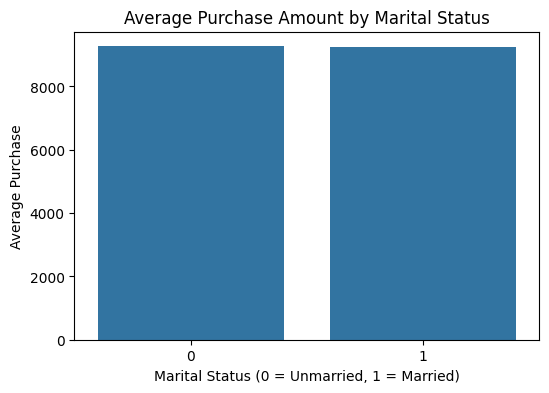

In [61]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=walmart,
    x="Marital_Status",
    y="Purchase",
    estimator="mean",
    errorbar=None
)

plt.title("Average Purchase Amount by Marital Status")
plt.xlabel("Marital Status (0 = Unmarried, 1 = Married)")
plt.ylabel("Average Purchase")

plt.show()

Step 4 — Compare distributions

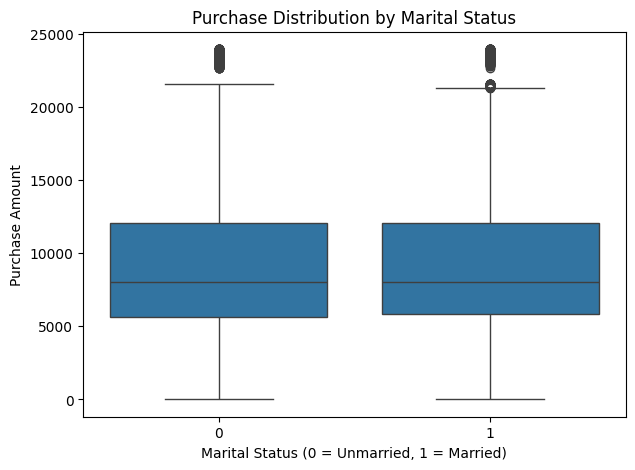

In [62]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=walmart,
    x="Marital_Status",
    y="Purchase"
)

plt.title("Purchase Distribution by Marital Status")
plt.xlabel("Marital Status (0 = Unmarried, 1 = Married)")
plt.ylabel("Purchase Amount")

plt.show()

Step 5 — 95% Confidence Interval

In [63]:
unmarried_ci = confidence_interval(unmarried_purchase, 0.95)
married_ci = confidence_interval(married_purchase, 0.95)

print("Unmarried 95% CI:", unmarried_ci)
print("Married 95% CI:", married_ci)

Unmarried 95% CI: (np.float64(9265.907618921507), np.float64(9248.616353737027), np.float64(9283.198884105987))
Married 95% CI: (np.float64(9261.174574082374), np.float64(9240.460315792989), np.float64(9281.888832371758))


Step 6 — Compare 90%, 95%, 99%

In [64]:
confidence_levels = [0.90, 0.95, 0.99]

for level in confidence_levels:

    unmarried_ci = confidence_interval(unmarried_purchase, level)
    married_ci = confidence_interval(married_purchase, level)

    print(f"\nConfidence Level: {level*100:.0f}%")
    print("Unmarried:", unmarried_ci)
    print("Married:", married_ci)


Confidence Level: 90%
Unmarried: (np.float64(9265.907618921507), np.float64(9251.396344426079), np.float64(9280.418893416934))
Married: (np.float64(9261.174574082374), np.float64(9243.79064243542), np.float64(9278.558505729326))

Confidence Level: 95%
Unmarried: (np.float64(9265.907618921507), np.float64(9248.616353737027), np.float64(9283.198884105987))
Married: (np.float64(9261.174574082374), np.float64(9240.460315792989), np.float64(9281.888832371758))

Confidence Level: 99%
Unmarried: (np.float64(9265.907618921507), np.float64(9243.182995563593), np.float64(9288.63224227942))
Married: (np.float64(9261.174574082374), np.float64(9233.951339733763), np.float64(9288.397808430984))


# Observation:
The average purchase amounts of unmarried (₹9,265.91) and married (₹9,261.17) customers are almost identical, with a difference of only about ₹4.73 per transaction. Their median purchase amounts are also very similar.

# Observation:
 The 95% confidence intervals for married and unmarried customers overlap substantially. This indicates that there is no clear evidence of a meaningful difference in average purchase amount between the two groups.

# Observation:
 As the confidence level increases from 90% to 99%, the intervals become wider. The confidence intervals overlap at all three confidence levels, indicating that marital status does not show a substantial difference in average transaction spending.

# Business Insight:
Walmart does not need to treat married and unmarried customers as fundamentally different segments based solely on their average transaction spending. Since their spending levels are nearly identical, promotional strategies should focus more on factors such as gender, age, product category and city rather than marital status alone.

# Conclusion:
**Married and unmarried customers have almost the same average spending per transaction**. Unlike the gender analysis, where the confidence intervals did not overlap, the confidence intervals for marital status overlap substantially. Therefore, marital status appears to have little practical impact on transaction spending in this dataset.

# 4.6 Age Analysis
Step 1 — Create Life-Stage Age Groups





In [65]:
def age_group(age):
    if age == "0-17":
        return "0-17"
    elif age == "18-25":
        return "18-25"
    elif age == "26-35":
        return "26-35"
    elif age == "36-45" or age == "46-50":
        return "36-50"
    else:
        return "51+"

walmart["Age_Group"] = walmart["Age"].apply(age_group)

walmart["Age_Group"].value_counts()

,count
Age_Group,
26-35,219587
36-50,155714
18-25,99660
51+,60005
0-17,15102


# Observation

Customers aged 26–35 form the largest group, accounting for approximately 40% of transactions. Customers aged 36–50 are the second-largest group. The 0–17 group contributes the fewest transactions.

Step 2 — Compare Basic Statistics


In [66]:
age_purchase = walmart.groupby(
    "Age_Group",
    observed=True
)["Purchase"].agg(
    ["count", "mean", "median", "std"]
)

age_purchase

,count,mean,median,std
Age_Group,,,,
0-17,15102,8933.464640,7986.0,5111.114046
18-25,99660,9169.663606,8027.0,5034.321997
26-35,219587,9252.690633,8030.0,5010.527303
36-50,155714,9295.331743,8053.0,5006.934324
51+,60005,9463.661678,8122.0,5061.161476


# Observation:
 Average spending generally increases with age. Customers aged 51+ have the highest average purchase amount of ₹9,463.66, while customers aged 0–17 have the lowest average purchase amount of ₹8,933.46.

Step 3 — Average Purchase by Age Group


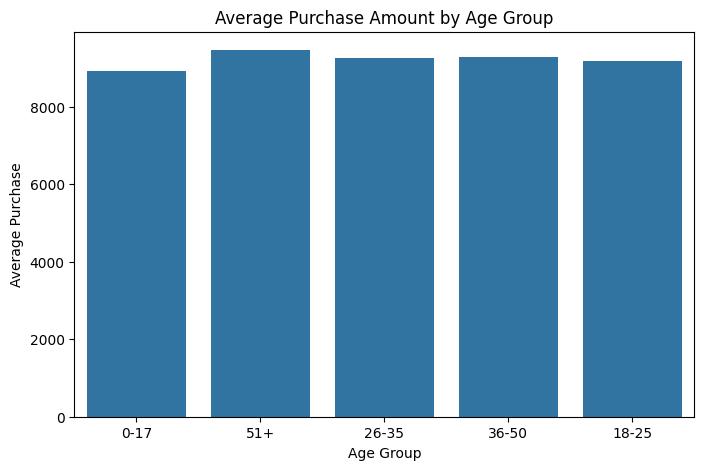

In [67]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=walmart,
    x="Age_Group",
    y="Purchase",
    estimator="mean",
    errorbar=None
)

plt.title("Average Purchase Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Purchase")

plt.show()

# Observation:
The purchase distributions across age groups are broadly similar, with considerable overlap. The 51+ group shows a relatively higher median purchase, while all age groups contain high-value outliers. Overall, age appears to have a moderate relationship with purchase amount rather than creating completely distinct spending patterns.

Step 4 — Distribution by Age Group


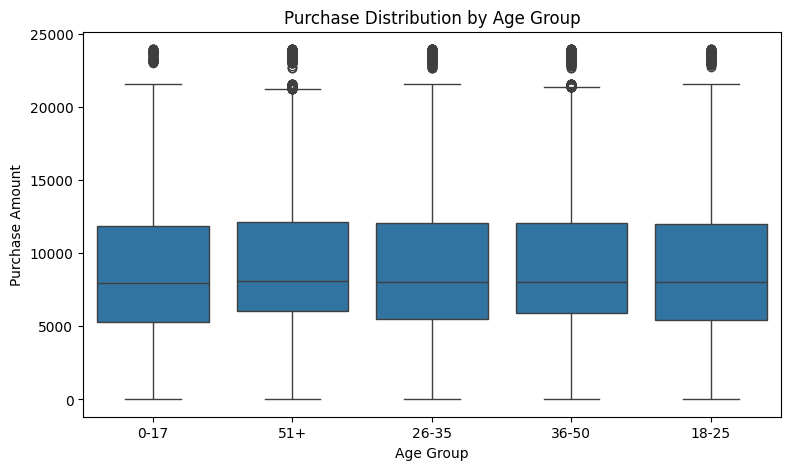

In [68]:

# Using boxplot:

plt.figure(figsize=(9,5))

sns.boxplot(
    data=walmart,
    x="Age_Group",
    y="Purchase"
)

plt.title("Purchase Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Purchase Amount")

plt.show()

# Observation:
Male customers have a higher average purchase amount than female customers across all age groups. The difference is consistent across the different life stages, suggesting that the gender-based spending pattern is not limited to a particular age group.

Step 5 — Age Group + Gender 📊



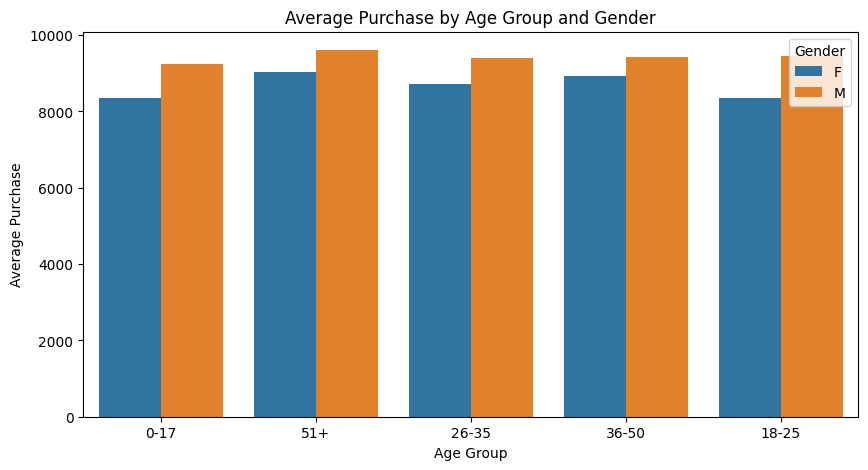

In [69]:

plt.figure(figsize=(10,5))

sns.barplot(
    data=walmart,
    x="Age_Group",
    y="Purchase",
    hue="Gender",
    estimator="mean",
    errorbar=None
)

plt.title("Average Purchase by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Average Purchase")

plt.show()

# Observation:
The confidence intervals show that average spending differs across several age groups. Most intervals are non-overlapping, while the 26–35 and 36–50 groups show a small overlap. The 51+ group has the highest estimated average spending, whereas the 0–17 group has the lowest.

Step 6 — Confidence Intervals by Age Group


In [70]:

# Here's where we connect Age back to CLT + statistical evidence.

# We'll calculate the 95% CI for every age group.

age_ci = {}

for age in walmart["Age_Group"].unique():
    data = walmart[walmart["Age_Group"] == age]["Purchase"]
    age_ci[age] = confidence_interval(data, 0.95)

age_ci

{'0-17': (np.float64(8933.464640444974),
  np.float64(8851.941436361221),
  np.float64(9014.987844528727)),
 '51+': (np.float64(9463.661678193484),
  np.float64(9423.16556655487),
  np.float64(9504.1577898321)),
 '26-35': (np.float64(9252.690632869888),
  np.float64(9231.733560884022),
  np.float64(9273.647704855754)),
 '36-50': (np.float64(9295.331742810537),
  np.float64(9270.462673595683),
  np.float64(9320.20081202539)),
 '18-25': (np.float64(9169.663606261289),
  np.float64(9138.40756914702),
  np.float64(9200.919643375557))}

# Observation:
 Increasing the confidence level from 90% to 95% and 99% increases the width of the confidence intervals. This reflects the trade-off between confidence and precision. The estimated average spending remains relatively stable across confidence levels.

Step 7 — Make the CI Results Easy to Read



In [71]:
age_ci_table = pd.DataFrame(
    age_ci,
    index=["Mean", "Lower CI", "Upper CI"]
).T

age_ci_table

,Mean,Lower CI,Upper CI
0-17,8933.464640,8851.941436,9014.987845
51+,9463.661678,9423.165567,9504.157790
26-35,9252.690633,9231.733561,9273.647705
36-50,9295.331743,9270.462674,9320.200812
18-25,9169.663606,9138.407569,9200.919643


Step 8 — 90%, 95%, 99% CI



In [72]:


for level in [0.90, 0.95, 0.99]:

    print(f"\nConfidence Level: {level*100:.0f}%")

    for age in sorted(walmart["Age_Group"].unique()):
        data = walmart[walmart["Age_Group"] == age]["Purchase"]
        ci = confidence_interval(data, level)

        print(
            f"{age}: "
            f"Mean={ci[0]:.2f}, "
            f"CI=({ci[1]:.2f}, {ci[2]:.2f})"
        )


Confidence Level: 90%
0-17: Mean=8933.46, CI=(8865.05, 9001.88)
18-25: Mean=9169.66, CI=(9143.43, 9195.89)
26-35: Mean=9252.69, CI=(9235.10, 9270.28)
36-50: Mean=9295.33, CI=(9274.46, 9316.20)
51+: Mean=9463.66, CI=(9429.68, 9497.65)

Confidence Level: 95%
0-17: Mean=8933.46, CI=(8851.94, 9014.99)
18-25: Mean=9169.66, CI=(9138.41, 9200.92)
26-35: Mean=9252.69, CI=(9231.73, 9273.65)
36-50: Mean=9295.33, CI=(9270.46, 9320.20)
51+: Mean=9463.66, CI=(9423.17, 9504.16)

Confidence Level: 99%
0-17: Mean=8933.46, CI=(8826.32, 9040.61)
18-25: Mean=9169.66, CI=(9128.59, 9210.74)
26-35: Mean=9252.69, CI=(9225.15, 9280.23)
36-50: Mean=9295.33, CI=(9262.65, 9328.02)
51+: Mean=9463.66, CI=(9410.44, 9516.88)


# **Business Insight:**
** Age appears to influence customer spending, with average purchase amounts generally increasing across older age groups. Customers aged 51+ have the highest average transaction value, while customers aged 0–17 have the lowest. **However, the spending distributions overlap considerably, indicating that age alone should not be used to define customer value.

# **Recommendation:**

Create targeted promotions for different age groups.
Focus premium and higher-value product promotions toward older customers, particularly the 51+ segment.
Use attractive offers and affordable product bundles to increase spending among younger customers.
Combine age with gender and product category to create more effective customer segments.
Avoid using age alone for marketing decisions because spending distributions across groups are still highly overlapping.

# **5️⃣ Final Insights — Overall Conclusion**

**5.1 Overall Findings**
📌 1. Gender
Male customers have an average purchase of approximately ₹9,437.53.
Female customers have an average purchase of approximately ₹8,734.57.
Male customers spend around 8.05% more per transaction than female customers.
The 95% confidence intervals do not overlap, providing strong evidence of a difference in average spending.

Insight: Gender is a meaningful factor associated with purchase amount.

📌 2. Central Limit Theorem
Sampling distributions of purchase means became approximately normal/bell-shaped.
Increasing sample size from 30 → 100 → 500 made the distribution narrower.
This demonstrates that larger samples provide more stable and precise estimates of the population mean.

Insight: CLT allows us to use sample data to make reliable conclusions about the larger customer population.

📌 3. Marital Status
Unmarried average: ₹9,265.91
Married average: ₹9,261.17
Difference is only about ₹4.73 per transaction.
Their confidence intervals overlap substantially at 90%, 95%, and 99%.

Insight: Marital status does not appear to be a meaningful factor in determining average purchase amount.

📌 4. Age
51+ customers have the highest average spending: ₹9,463.66.
0–17 customers have the lowest: ₹8,933.46.
Average spending generally increases with age.
However, the distributions still have considerable overlap.

Insight: Age appears to influence spending, but it should not be considered independently.

📌 5. Age + Gender

Our analysis showed that male customers have higher average spending than female customers across all age groups.

Insight: Gender differences remain visible even after looking at different age groups, making gender + age a potentially useful combination for customer segmentation.

status."

# 5.2 Statistical Summary


The analysis shows that customer spending behavior varies across different demographic factors. Male customers have a substantially higher average purchase amount than female customers, and the non-overlapping confidence intervals provide strong evidence of this difference. Age also shows a pattern, with older customers generally having higher average transaction values. In contrast, married and unmarried customers have almost identical spending levels, with overlapping confidence intervals. The Central Limit Theorem (CLT) analysis further demonstrates that larger samples provide more stable estimates of average spending. Overall, Walmart can benefit from using gender and age as important segmentation factors while treating marital status as a less influential factor.

# 6️⃣ Recommendations

1.Focus on Male Customers for Higher-Value Promotions

Male customers have a higher average transaction value than female customers.

Action: Promote premium products, product bundles and higher-value offers to male customers to increase revenue per transactio

2.Increase Engagement with Female Customers

Female customers have lower average spending per transaction compared with male customers.

Action: Introduce targeted discounts, product bundles and personalized offers to encourage higher basket values.

3.Target Older Customers with Premium Products

The 51+ age group has the highest average purchase amount.

Action: Promote premium and higher-value products to this customer segment and design offers around products relevant to their needs.

4.Encourage Spending Among Younger Customers

The 0–17 and younger age groups have relatively lower average purchase amounts.

Action: Use affordable bundles, discounts and family-oriented promotions to encourage larger purchases.

5.Combine Gender + Age for Better Targeting

Our analysis shows that male customers spend more than female customers across all age groups.

Action: Instead of creating one promotion for everyone, Walmart can create offers based on both age and gender.

6.Don't Overuse Marital Status for Segmentation

Married and unmarried customers have almost identical average spending.

Action: Walmart should not make major marketing decisions based solely on marital status. Resources should instead focus on stronger factors such as gender, age and product preferences.

7.Promote High-Value Product Categories

Our product-category analysis showed that some categories have considerably higher average purchase values than others.

Action: Walmart can give greater visibility to high-value categories through promotions, product recommendations and strategic placement during major shopping events like Black Friday.

**# Final Recommendation:**

 Walmart should adopt a more targeted customer strategy rather than offering the same promotions to all customers. Gender and age can be used as important segmentation factors because they show differences in spending behavior. Higher-value products can be promoted to segments with stronger spending patterns, while discounts and bundles can encourage lower-spending segments to increase their purchase value. Marital status should receive less emphasis because spending patterns between married and unmarried customers are very similar.